In [ ]:
import numpy as np
import pandas as pd
from sklearn import set_config
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
    brier_score_loss, f1_score
)
from sklearn.calibration import calibration_curve
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the data
data = pd.read_csv("heart.csv")

# Pick target column and feature columns
target = "HeartDisease"
y = data[target]

# numeric and categorical input columns
num_cols = ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]
cat_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
X = data[num_cols + cat_cols]


# Train/test split (stratified using target column)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=27
)

# Preprocess + Model Pipeline
# Need to standardize numeric features
# One hot encode categorical features
# Linear regression outputs a continuous score, so we will use a threshold
pre = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

lin = Pipeline(steps=[
    ("preprocessor", pre),
    ("classifier", LinearRegression())
])


[Cross-Validtion] Best F1 threshold on TRAIN folds: 0.477 (F1=0.881)


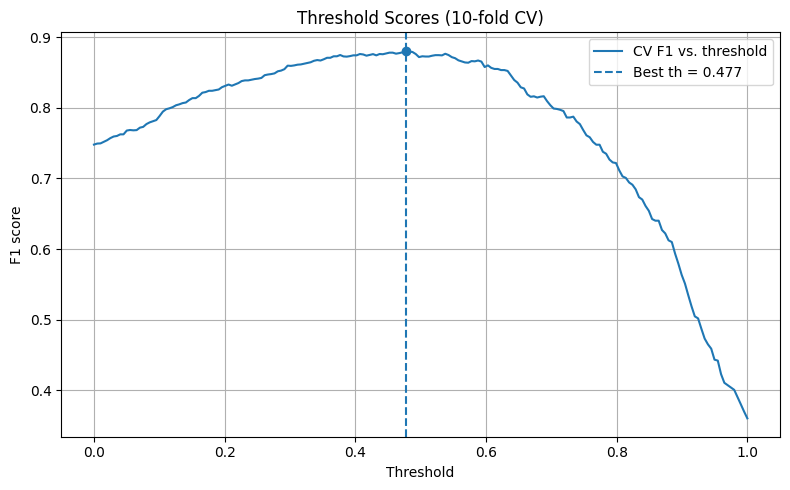

In [ ]:
# Tune the decision threshold using CV on the training set
# Using k-fold validation on the training set
# for each fold we predict on the validation set
# At the end choose the threshold that gives the best F1 on those scores
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_prob = np.zeros(len(y_train), dtype=float)
fold_true = y_train.to_numpy()

for tr_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    # new copy of pipeline
    lin_cv = clone(lin)

    # train on training fold
    lin_cv.fit(X_tr, y_tr)

    # continuous predictions
    y_val_cont = lin_cv.predict(X_val)

    # store predictions for this validation fold
    fold_prob[val_idx] = y_val_cont

# try many thresholds and pick the one with the best F1 on the
# k-fold training predictions
ths = np.linspace(0.0, 1.0, 200)
f1s = [f1_score(fold_true, (fold_prob >= th).astype(int)) for th in ths]
best_th = float(ths[int(np.argmax(f1s))])
print(f"\n[Cross-Validtion] Best F1 threshold on TRAIN folds: {best_th:.3f} (F1={max(f1s):.3f})")

# Refit pipeline on all of the training data
lin.fit(X_train, y_train)

# CV threshold chart
cv_sweep = pd.DataFrame({"threshold": ths, "f1": f1s})
best_f1 = float(np.max(f1s))

plt.figure(figsize=(8,5))
plt.plot(cv_sweep["threshold"], cv_sweep["f1"], label="CV F1 vs. threshold")
plt.axvline(best_th, linestyle="--", label=f"Best th = {best_th:.3f}")
plt.scatter([best_th], [best_f1], zorder=3)
plt.title("Threshold Scores (10-fold CV)")
plt.xlabel("Threshold")
plt.ylabel("F1 score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Evaluate on the test set with the tuned threshold
y_cont_test = lin.predict(X_test)
y_prob_test = np.clip(y_cont_test, 0, 1)
y_pred_test = (y_prob_test >= best_th).astype(int)

print("Threshold:", best_th)
print("Accuracy:", accuracy_score(y_test, y_pred_test))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))

Threshold: 0.47738693467336685
Accuracy: 0.8826086956521739
ROC-AUC: 0.937007874015748

Confusion Matrix:
 [[ 85  18]
 [  9 118]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.83      0.86       103
           1       0.87      0.93      0.90       127

    accuracy                           0.88       230
   macro avg       0.89      0.88      0.88       230
weighted avg       0.88      0.88      0.88       230



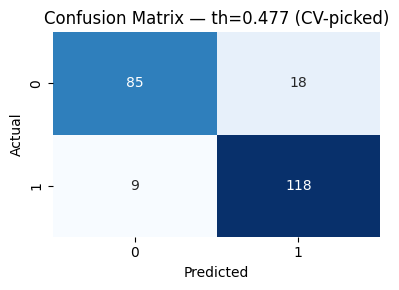

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"Confusion Matrix — th={best_th:.3f} (CV-picked)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


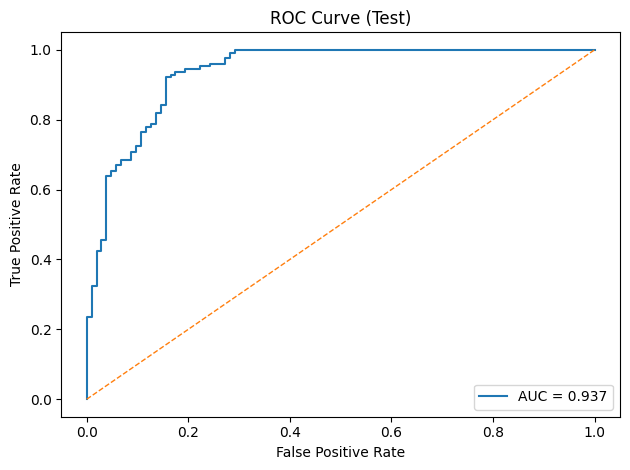

In [ ]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "--", linewidth=1)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test)")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

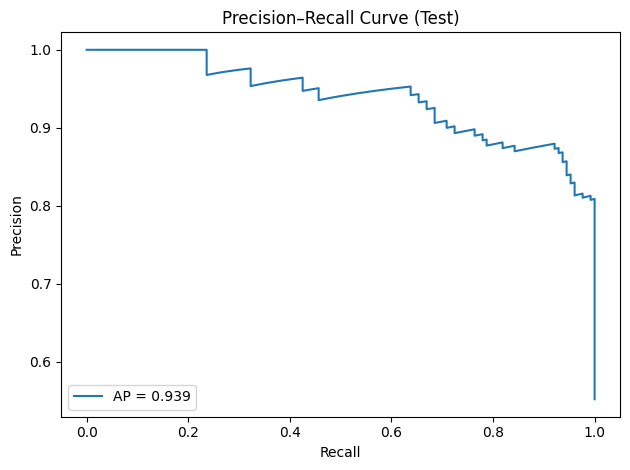

In [ ]:
# Precision–Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)
plt.figure()
plt.plot(rec, prec, label=f"AP = {ap:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test)")
plt.legend(loc="lower left"); plt.tight_layout(); plt.show()

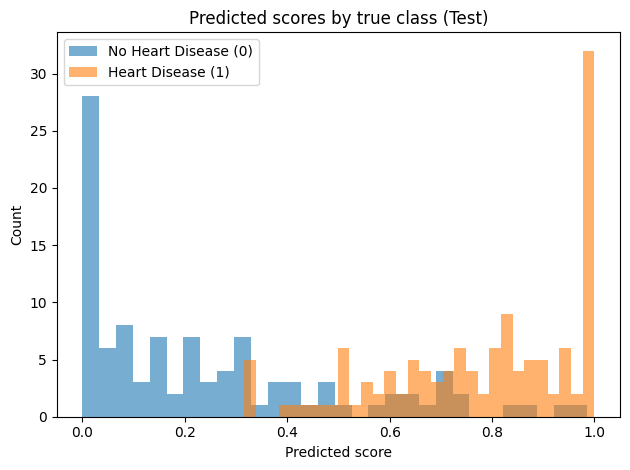

In [ ]:
# Score distribution by class
plt.figure()
plt.hist(y_prob_test[y_test == 0], bins=30, alpha=0.6, label="No Heart Disease (0)")
plt.hist(y_prob_test[y_test == 1], bins=30, alpha=0.6, label="Heart Disease (1)")
plt.xlabel("Predicted score"); plt.ylabel("Count")
plt.title("Predicted scores by true class (Test)")
plt.legend(); plt.tight_layout(); plt.show()


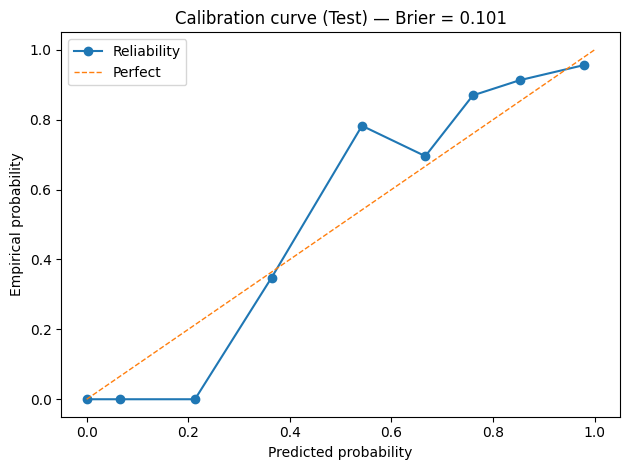

In [ ]:
# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, y_prob_test)
plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="Reliability")
plt.plot([0, 1], [0, 1], "--", linewidth=1, label="Perfect")
plt.xlabel("Predicted probability"); plt.ylabel("Empirical probability")
plt.title(f"Calibration curve (Test) — Brier = {brier:.3f}")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
set_config(transform_output="pandas")
pre_fitted = lin.named_steps["preprocessor"]
feature_names = pre_fitted.get_feature_names_out()

coef_vec = lin.named_steps["classifier"].coef_.ravel()
intercept = float(lin.named_steps["classifier"].intercept_)

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient_transformed": coef_vec,
    "abs_coef": np.abs(coef_vec)
}).sort_values("abs_coef", ascending=False).drop(columns="abs_coef")

# print the linear model as a chart
print("\nLinear model:")
print(f"Intercept: {intercept:.6f}")
print(coef_df.head(25).to_string(index=False))


# Print output equation
equation = f"y_hat = {intercept:.6f}"
for f, w in zip(feature_names, coef_vec):
    sign = "+" if w >= 0 else "-"
    equation += f" {sign} {abs(w):.6f}*[{f}]"
print("\nEquation:")
print(equation)


Linear model:
Intercept: 0.462161
               feature  coefficient_transformed
      cat__ST_Slope_Up                -0.183368
    cat__ST_Slope_Flat                 0.182987
cat__ChestPainType_ASY                 0.146247
cat__ChestPainType_ATA                -0.092617
            cat__Sex_M                 0.079924
            cat__Sex_F                -0.079924
 cat__ExerciseAngina_Y                 0.077045
 cat__ExerciseAngina_N                -0.077045
      num__Cholesterol                -0.060174
          num__Oldpeak                 0.059532
cat__ChestPainType_NAP                -0.052584
        num__FastingBS                 0.052200
   cat__RestingECG_LVH                 0.028522
              num__Age                 0.024265
    cat__RestingECG_ST                -0.019398
cat__RestingECG_Normal                -0.009124
            num__MaxHR                -0.008459
        num__RestingBP                 0.005878
 cat__ChestPainType_TA                -0.001046
    c